In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "context_scaling" / "scripts"))
sys.path.insert(0, str(REPO_ROOT / "src"))


## Helpers

### Fetching & config wrangling

In [3]:
def fetch_runs_df(tags, project="ideas_cv/llm-random-test", negative_tags=None):
    """Fetch wandb runs matching ALL `tags` into a flat dataframe.

    Columns are prefixed sys/, config/, summary/. Runs carrying any of
    `negative_tags` are dropped. (WandB reads WANDB_API_KEY from the env.)
    """
    if isinstance(tags, str):
        tags = [tags]
    print(f"tags: {tags}")

    filters = {"$and": [{"tags": t} for t in tags]} if tags else {}
    runs = wandb.Api().runs(path=project, filters=filters)

    rows = []
    for run in runs:
        row = {"sys/id": run.id, "sys/name": run.name,
               "sys/state": run.state, "sys/tags": run.tags}
        row.update({f"config/{k}": v for k, v in run.config.items()})
        row.update({f"summary/{k}": v for k, v in run.summary._json_dict.items()})
        rows.append(row)
    df = pd.DataFrame(rows)

    if not df.empty and negative_tags:
        neg = {negative_tags} if isinstance(negative_tags, str) else set(negative_tags)
        df = df[~df["sys/tags"].apply(lambda ts: bool(neg & set(ts)))]

    print(f"df shape: {df.shape}")
    return df


In [4]:
def flatten_config(df, sep="/"):
    """Expand nested dict `config/*` columns (wandb stores nested OmegaConf)
    into flat columns like `config/trainer/learning_rate`."""
    config_cols = [c for c in df.columns if c.startswith("config/")]

    def walk(prefix, value, out):
        if isinstance(value, dict):
            for k, v in value.items():
                walk(f"{prefix}{sep}{k}", v, out)
        else:
            out[prefix] = value

    flat_rows = []
    for _, row in df.iterrows():
        out = {}
        for c in config_cols:
            walk(c, row[c], out)
        flat_rows.append(out)

    flat = pd.DataFrame(flat_rows, index=df.index)
    return pd.concat([df.drop(columns=config_cols), flat], axis=1)


def effective_lr(config_lr):
    """Raw config LR -> LR used in training (a value >= 1 means 2**-value)."""
    if pd.isnull(config_lr):
        return config_lr
    return config_lr if config_lr < 1.0 else 2.0 ** -config_lr


### Loss-vs-LR plotting

In [5]:
LR_COLORS = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00",
             "#6a3d9a", "#a65628", "#000000"]


def _final_loss_df(df, lr_col, loss_col, n_steps_col, step_col, group_cols):
    """One row per run: lr, final_loss, completion flag, and the group columns."""
    out = df[[lr_col, loss_col, step_col, n_steps_col, *group_cols]].copy()
    out = out.rename(columns={lr_col: "lr", loss_col: "final_loss"})
    out = out[out["final_loss"].notnull()]
    out["complete"] = out[step_col] + 1 >= out[n_steps_col]
    return out


def _style_lr_axis(ax, title, ylim, legend_loc, ax_labels_font, tick_font, title_font):
    ax.legend(loc=legend_loc)
    ax.set_xlabel("Learning Rate", fontsize=ax_labels_font)
    ax.set_ylabel("Final Eval Loss", fontsize=ax_labels_font)
    ax.tick_params(axis="both", labelsize=tick_font)
    ax.set_title(title or "Final Loss vs Learning Rate", fontsize=title_font)
    ax.set_xscale("log", base=2)
    ax.grid(True)
    if ylim is not None:
        ax.set_ylim(ylim)


def plot_loss_vs_lr(
    df,
    main_variables,
    lr_col="config/trainer/learning_rate",
    loss_col="summary/steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    step_col="summary/step",
    ax=None,
    ylim=None,
    title=None,
    color_map=None,
    var_labels=None,
    legend_loc="best",
    ax_labels_font=12,
    tick_font=12,
    title_font=12,
):
    """Plot final loss vs LR, one line per `main_variables` combo.

    Complete runs (step+1 >= n_steps) -> circles + solid line; running runs ->
    squares + dashed line. `color_map` maps grid-value tuples to colors for a
    shared palette across subplots; otherwise LR_COLORS is used in group order.
    """
    required = [lr_col, loss_col, n_steps_col, step_col, *main_variables]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = _final_loss_df(df, lr_col, loss_col, n_steps_col, step_col, main_variables)
    var_labels = var_labels or {}
    styles = {True: dict(marker="o", linestyle="-"),
              False: dict(marker="s", linestyle="--", markersize=6)}

    standalone = ax is None
    ax = ax or plt.gca()

    for i, (vals, group) in enumerate(data.groupby(main_variables, sort=True)):
        vals = vals if isinstance(vals, tuple) else (vals,)
        color = color_map.get(vals) if color_map else LR_COLORS[i % len(LR_COLORS)]
        label = ", ".join(f"{var_labels.get(n, n)}: {v}"
                          for n, v in zip(main_variables, vals))
        for complete, style in styles.items():
            part = group[group["complete"] == complete]
            if part.empty:
                continue
            means = part.groupby("lr")["final_loss"].mean().sort_index()
            ax.plot(means.index.to_numpy(), means.to_numpy(),
                    color=color, label=label, **style)
            label = "_nolegend_"  # one legend entry per group

    _style_lr_axis(ax, title, ylim, legend_loc,
                   ax_labels_font, tick_font, title_font)
    if standalone:
        plt.show()


### Per-plot data prep

In [6]:
def prep_plot_df(df):
    """Flatten config, tag each run pc/pc_distil/hp/hp_distil, resolve LR."""
    df = flatten_config(df)
    target = df["config/trainer/_target_"].fillna("").astype(str)
    method = np.where(target.str.contains("projected_compression.trainer"), "pc", "hp")
    distil = target.str.contains("distillation", case=False)
    df["config_type"] = [m + ("_distil" if d else "") for m, d in zip(method, distil)]
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(effective_lr)
    return df


def classify_by_tags(tags):
    """(config_type, compression key) from a run's tags, or (None, None)."""
    tags = set(tags)
    if "hard_pruning" in tags:
        method = "HP"
    elif "projected_compression" in tags:
        method = "PC"
    else:
        return None, None
    config_type = method + ("D" if "distillation" in tags else "")
    comp = next((c for c in COMPRESSION_RATE_LABELS if c in tags), None)
    return config_type, comp


def build_qwen_tokens_loss_df(
    tags=("qwen", "1.7B"),
    negative_tags=("pc_weights_lr_ratio", "remove"),
    project="ideas_cv/llm-random-test",
    loss_col="summary/steps/100/train/loss",
    n_steps_col="config/trainer/n_steps",
):
    """Long df (config_type, compression_rate, processed_tokens, loss).

    Reruns / LR-sweeps are collapsed to the best (lowest-loss) run per group.
    """
    df = flatten_config(fetch_runs_df(list(tags), project=project,
                                      negative_tags=list(negative_tags)))
    df = df[(df["sys/state"] == "finished") & df[loss_col].notnull()]
    df = df[df[n_steps_col].isin(TOKEN_LABELS)]

    rows = []
    for _, r in df.iterrows():
        config_type, comp = classify_by_tags(r["sys/tags"])
        if config_type is None or comp is None:
            continue
        rows.append({
            "config_type": config_type,
            "compression_rate": COMPRESSION_RATE_LABELS[comp],
            "processed_tokens": TOKEN_LABELS[int(r[n_steps_col])],
            "loss": r[loss_col],
        })

    long_df = pd.DataFrame(rows)
    return (long_df.sort_values("loss")
            .groupby(["config_type", "compression_rate", "processed_tokens"],
                     as_index=False)
            .first())


def prep_proj_lr_df(df):
    """Add proj_lr (effective base LR x pc_weights_lr_ratio), base_lr, comp_rate."""
    df = flatten_config(df)
    base_lr = df["config/trainer/learning_rate"].apply(effective_lr)
    df["base_lr"] = base_lr
    df["proj_lr"] = base_lr * df["config/projected_compression/pc_weights_lr_ratio"]
    df["comp_rate"] = df["config/common/dmodel"].map(DMODEL_TO_COMP)
    return df


def plot_loss_vs_tokens(df, title=None, ax_labels_font=18, tick_font=15,
                        title_font=20, legend_loc="upper right", ylims=None):
    """One subplot per compression rate: loss vs processed tokens, line per method."""
    token_order = list(TOKEN_LABELS.values())
    comp_rates = ["50%", "70%", "90%"]
    ylims = ylims or {}  # per-subplot y range keyed by compression rate

    fig, axes = plt.subplots(1, len(comp_rates), figsize=(24, 6), sharey=False)
    for ax, comp_rate in zip(axes, comp_rates):
        subset = df[df["compression_rate"] == comp_rate]
        for config_type in CONFIG_TYPE_ORDER:
            line = (subset[subset["config_type"] == config_type]
                    .set_index("processed_tokens")
                    .reindex(token_order)
                    .dropna(subset=["loss"]))
            if line.empty:
                continue
            ax.plot(line.index, line["loss"], marker="o",
                    color=CONFIG_TYPE_COLORS[config_type], label=config_type)
        ax.set_xlabel("Processed tokens", fontsize=ax_labels_font)
        ax.set_ylabel("Loss", fontsize=ax_labels_font)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.set_title(f"Compression rate: {comp_rate}", fontsize=title_font)
        ax.grid(True)
        ax.legend(loc=legend_loc, fontsize=tick_font, title="Method")
        if ylims.get(comp_rate) is not None:
            ax.set_ylim(ylims[comp_rate])

    if title:
        fig.suptitle(title, fontsize=title_font + 2)
    fig.tight_layout()
    plt.show()


In [7]:
# shared across the notebook
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"


## QWEN LR grid

In [8]:
# LR grids as a grid: rows = processed tokens, cols = compression rates.
token_tags = ["1B_train", "2B_train", "4B_train", "8B_train"]
pcts = ["50p", "30p", "10p"]
mv = "config_type"
loss_col = "summary/steps/100/train/loss"
palette = ["#5F0202", "#00336D", "#ff0004", "#006EFF"]
# fixed color per config_type so colors are consistent across the whole grid
all_config_types = ["hp", "hp_distil", "pc", "pc_distil"]
color_map = {(ct,): palette[i % len(palette)] for i, ct in enumerate(all_config_types)}
# per-column y limits (50p, 30p, 10p); edit the last entry for the 10% comp column
ylims = [(2.4, 3.4), (2.4, 3.4), (2.4, 3.4)]


tags: ['1.7B', 'qwen', '1B_train', '50p']


wandb: Currently logged in as: j321m (j321m-uniwersytet-warszawski) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


KeyboardInterrupt: 

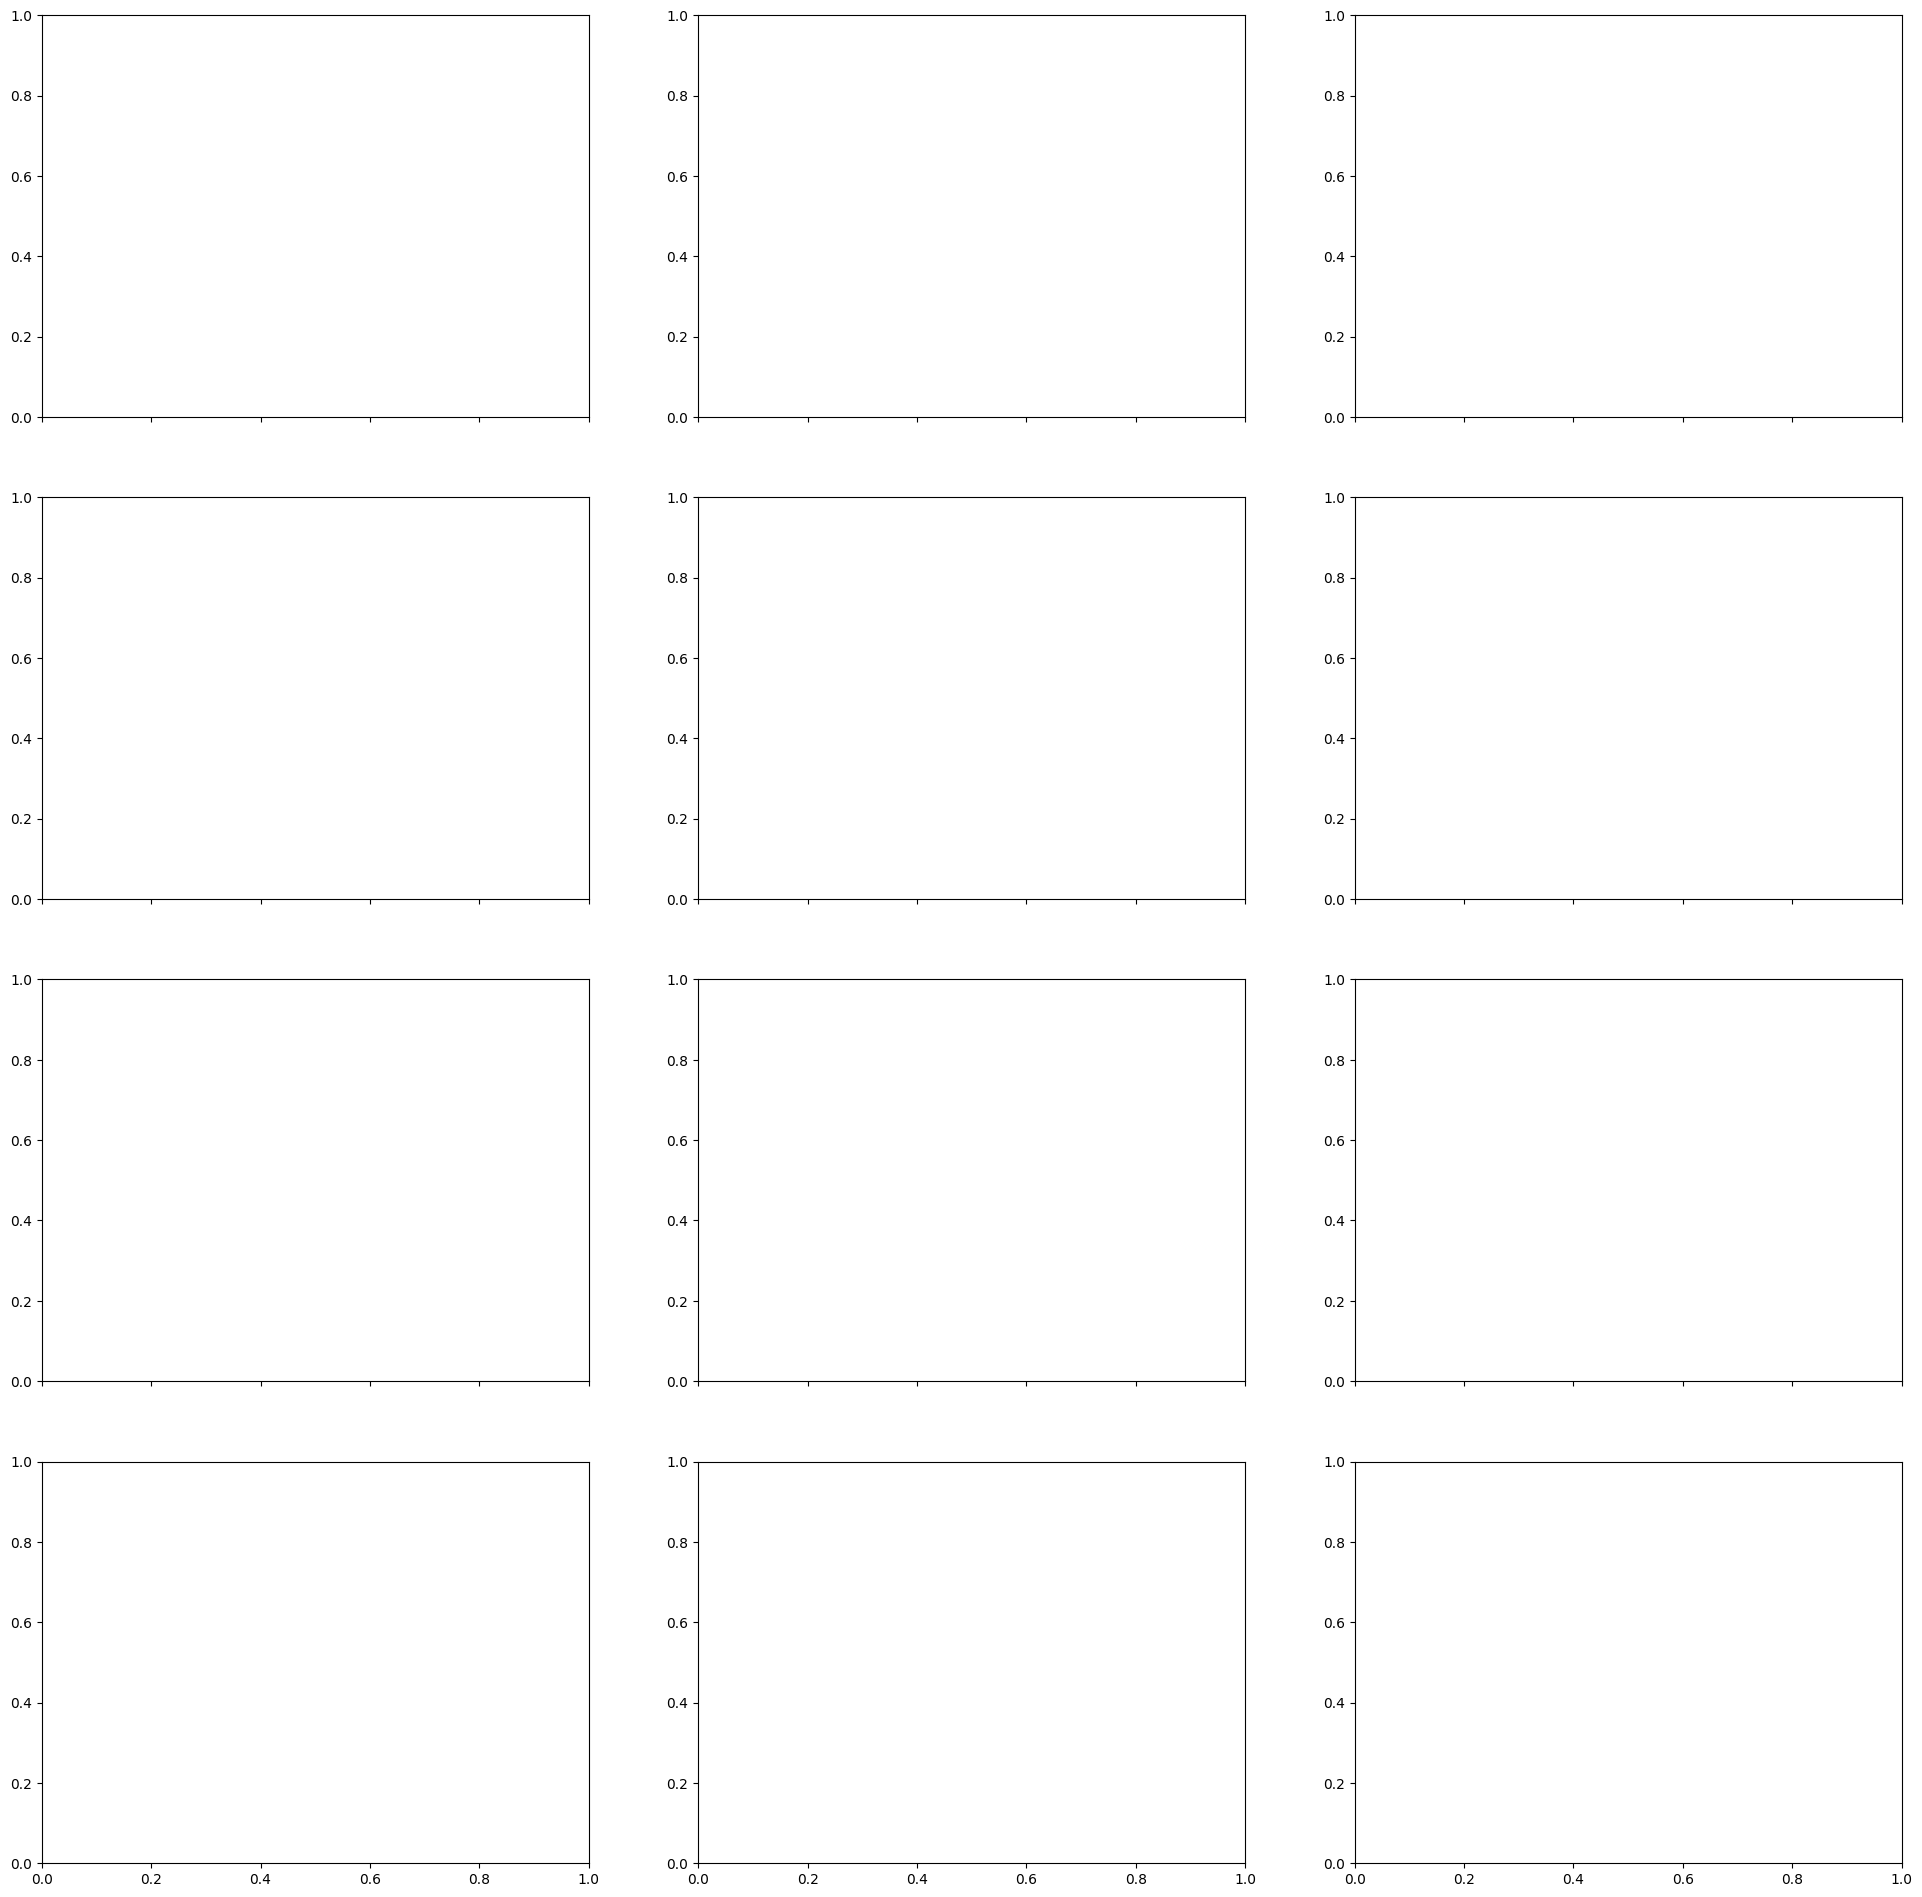

In [9]:
fig, axes = plt.subplots(
    len(token_tags),
    len(pcts),
    figsize=(24, 6 * len(token_tags)),
    sharey="col",
    sharex="col",
)
for row, token_tag in enumerate(token_tags):
    tokens_short = token_tag.split("_")[0]  # "1B_train" -> "1B"
    for col, pct in enumerate(pcts):
        ax = axes[row, col]
        tags = ["1.7B", "qwen", token_tag, pct]
        df = fetch_runs_df(tags, project=project,
                           negative_tags=["remove", "pc_weights_lr_ratio"])
        if df.empty:
            ax.set_title(f"{tokens_short} {pct[:-1]}% comp (no runs)", fontsize=20)
            ax.set_xscale("log", base=2)
            ax.set_ylim(ylims[col])
            ax.grid(True)
            continue
        plot_loss_vs_lr(
            prep_plot_df(df),
            main_variables=[mv],
            loss_col=loss_col,
            legend_loc="upper left",
            title=f"{tokens_short}-tokens {pct[:-1]}% comp LR grid",
            ax_labels_font=18,
            tick_font=15,
            title_font=20,
            color_map=color_map,
            ax=ax,
            ylim=ylims[col],
        )

fig.tight_layout()
plt.show()


## QWEN PC vs HP loss vs processed tokens

One subplot per compression rate (90% / 70% / 50%), loss vs processed tokens,
one line per method (PC, PCD, HP, HPD). Reruns/LR-sweeps are collapsed to the
best (lowest final loss) run per (method, compression, tokens) group.

In [ ]:
# Qwen: dmodel-tag -> compression rate, n_steps -> processed tokens.
COMPRESSION_RATE_LABELS = {"10p": "90%", "30p": "70%", "50p": "50%"}
TOKEN_LABELS = {2048: "1BT", 4096: "2BT", 8192: "4BT", 16384: "8BT"}
CONFIG_TYPE_ORDER = ["PC", "PCD", "HP", "HPD"]
CONFIG_TYPE_COLORS = {
    "PC": "#ff0004",
    "PCD": "#006EFF",
    "HP": "#5F0202",
    "HPD": "#00336D",
}
TOKENS_LOSS_TAGS = ("qwen", "1.7B")


In [ ]:
qwen_tokens_loss_df = build_qwen_tokens_loss_df(tags=TOKENS_LOSS_TAGS)


tags: ['qwen', '1.7B']
df shape: (148, 117)


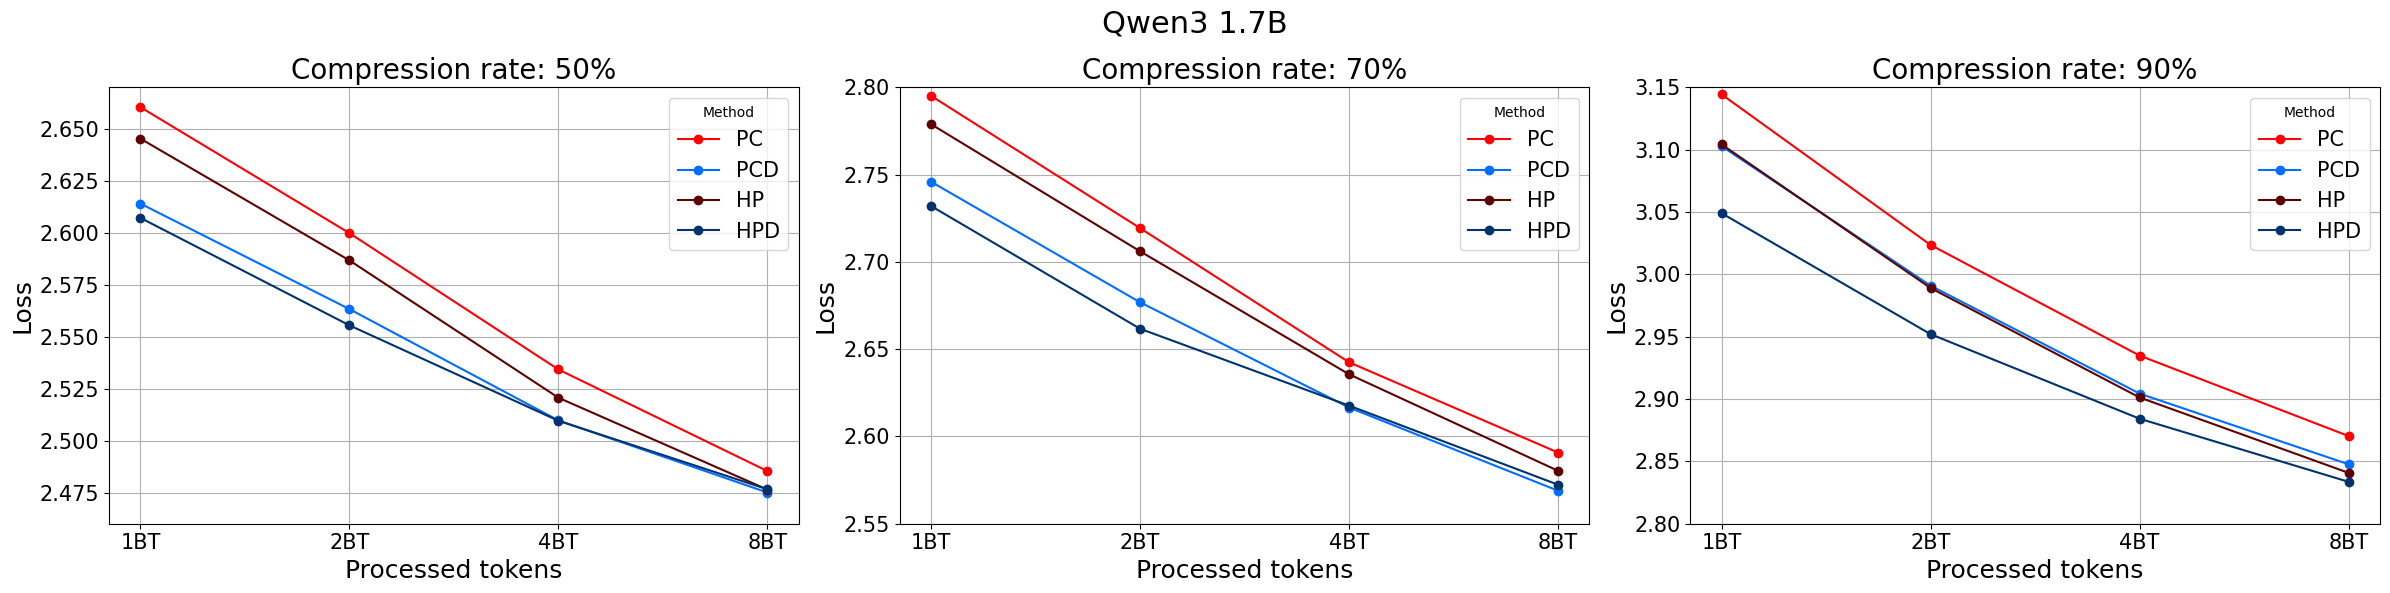

In [ ]:
# per-subplot y range; tweak each entry independently
ylims = {"90%": (2.8, 3.15), "70%": (2.55, 2.8), "50%": (2.46, 2.67)}
plot_loss_vs_tokens(qwen_tokens_loss_df, title="Qwen3 1.7B", ylims=ylims)


## QWEN PC projection-matrix LR grid

Sweep over `pc_weights_lr_ratio` (the LR multiplier applied to the projection
matrices, not the aux weights). x-axis = **projection-matrix LR** = effective
base LR x `pc_weights_lr_ratio`; one line per (compression rate, base LR).
Everything on one picture. Runs selected by the `pc_weights_lr_ratio` tag.

In [ ]:
# dmodel -> compression rate (see infrastructure.metric_logger tags in the config)
DMODEL_TO_COMP = {448: "90%", 960: "70%", 1344: "50%"}
COMP_RATES = ["90%", "70%", "50%"]
PROJ_LR_TAGS = ["qwen", "1.7B", "pc_weights_lr_ratio"]
PROJ_LR_LOSS_COL = "summary/steps/100/train/loss"

df = fetch_runs_df(PROJ_LR_TAGS, negative_tags=["remove"])
plot_df = prep_proj_lr_df(df)

# best (lowest-loss) HP run from the 1B-token original LR grid, per compression rate
COMP_TO_PCT = {"90%": "10p", "70%": "30p", "50%": "50p"}
best_hp_1b = {}
best_new_pc_1b = {}  # newly trained fp32 PC runs (current config)
for comp_rate, pct in COMP_TO_PCT.items():
    hp_df = fetch_runs_df(["1.7B", "qwen", "1B_train", pct],
                          project=project, negative_tags=["remove", "pc_weights_lr_ratio"])
    if not hp_df.empty:
        hp_df = prep_plot_df(hp_df)
        losses = hp_df[hp_df["config_type"] == "hp"][PROJ_LR_LOSS_COL].dropna()
        if not losses.empty:
            best_hp_1b[comp_rate] = losses.min()

    pc_df = fetch_runs_df(["1.7B", "qwen", "1B_train", pct, "fp32"],
                          project=project, negative_tags=["remove", "pc_weights_lr_ratio"])
    if not pc_df.empty:
        pc_df = prep_plot_df(pc_df)
        pc_losses = pc_df[pc_df["config_type"] == "pc"][PROJ_LR_LOSS_COL].dropna()
        if not pc_losses.empty:
            best_new_pc_1b[comp_rate] = pc_losses.min()


tags: ['qwen', '1.7B', 'pc_weights_lr_ratio']


wandb: Currently logged in as: j321m (j321m-uniwersytet-warszawski) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


df shape: (60, 104)
tags: ['1.7B', 'qwen', '1B_train', '10p']
df shape: (14, 117)
tags: ['1.7B', 'qwen', '1B_train', '10p', 'fp32']
df shape: (1, 104)
tags: ['1.7B', 'qwen', '1B_train', '30p']
df shape: (14, 117)
tags: ['1.7B', 'qwen', '1B_train', '30p', 'fp32']
df shape: (1, 104)
tags: ['1.7B', 'qwen', '1B_train', '50p']
df shape: (28, 117)
tags: ['1.7B', 'qwen', '1B_train', '50p', 'fp32']
df shape: (1, 104)


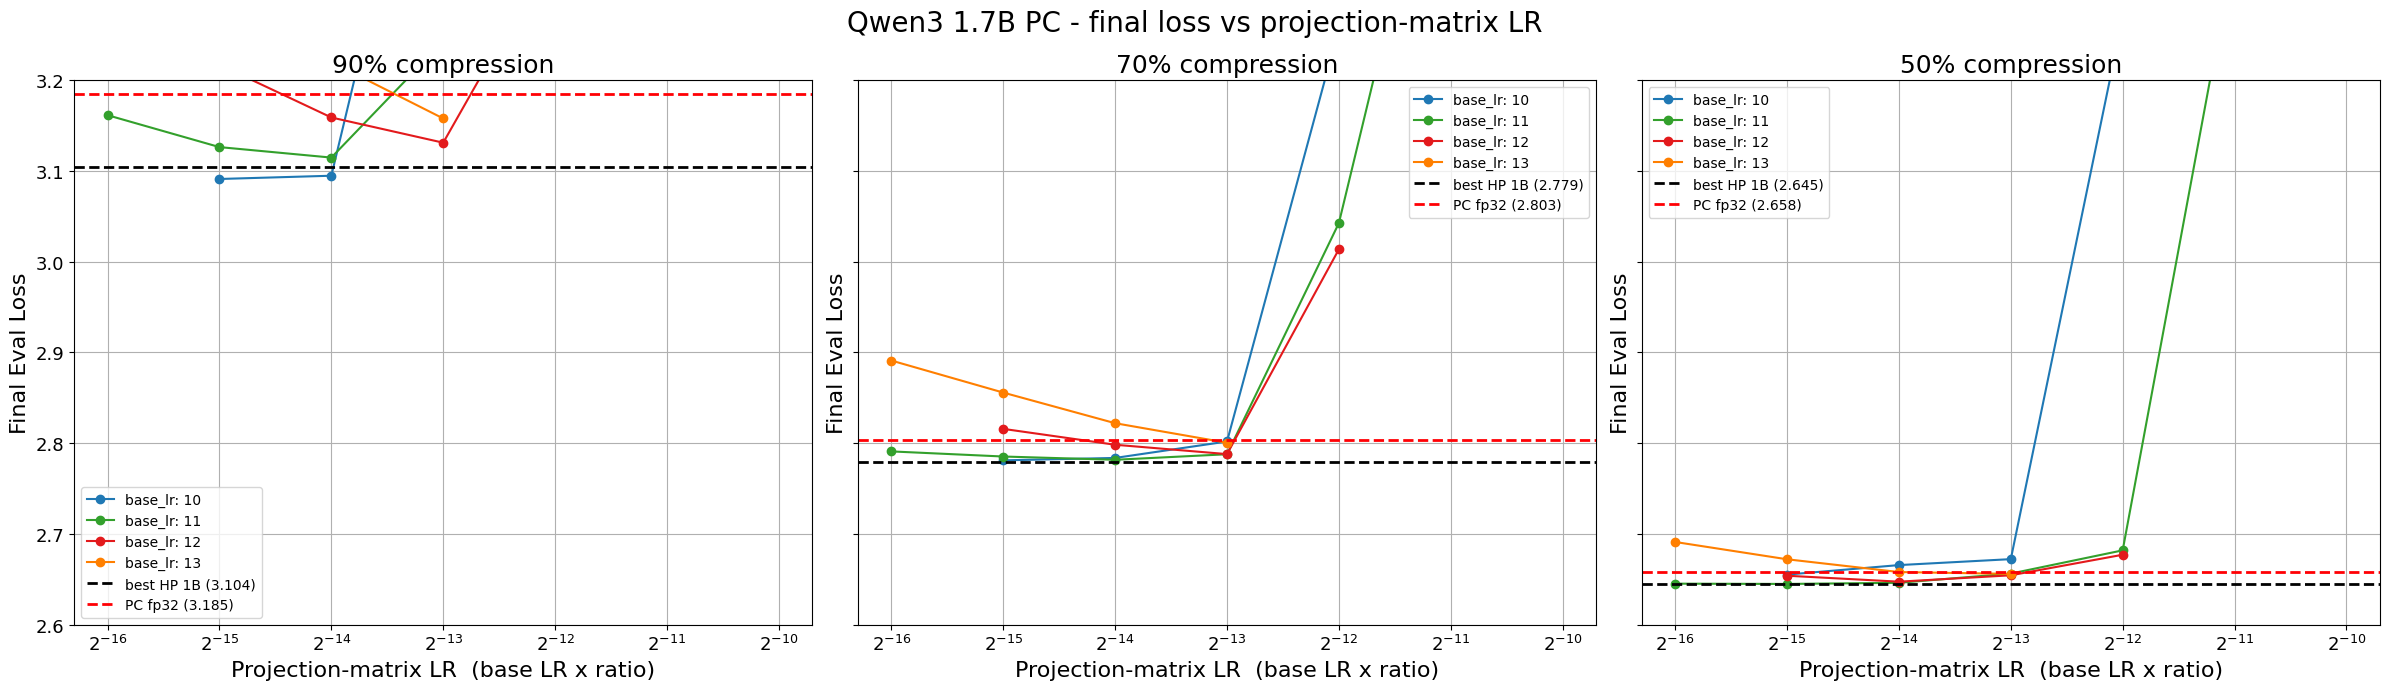

In [ ]:
# one subplot per compression rate; x-axis = projection-matrix LR, one line per base LR
fig, axes = plt.subplots(1, len(COMP_RATES), figsize=(8 * len(COMP_RATES), 7), sharey=True)
for ax, comp_rate in zip(axes, COMP_RATES):
    subset = plot_df[plot_df["comp_rate"] == comp_rate]
    if subset.empty:
        ax.set_title(f"{comp_rate} comp (no runs)", fontsize=18)
        ax.set_xscale("log", base=2)
        ax.grid(True)
        continue
    plot_loss_vs_lr(
        subset,
        main_variables=["config/trainer/learning_rate"],
        lr_col="proj_lr",
        loss_col=PROJ_LR_LOSS_COL,
        var_labels={"config/trainer/learning_rate": "base_lr"},
        title=f"{comp_rate} compression",
        ax=ax,
        legend_loc="best",
        ax_labels_font=16,
        tick_font=13,
        title_font=18,
        ylim=(2.6, 3.2),
    )
    ax.set_xlabel("Projection-matrix LR  (base LR x ratio)", fontsize=16)
    # best HP 1B-token baseline from the original LR grid
    if comp_rate in best_hp_1b:
        ax.axhline(
            best_hp_1b[comp_rate],
            color="black",
            linestyle="--",
            linewidth=2,
            label=f"best HP 1B ({best_hp_1b[comp_rate]:.3f})",
        )
    # newly trained PC models (current config, no proj-LR sweep)
    if comp_rate in best_new_pc_1b:
        ax.axhline(
            best_new_pc_1b[comp_rate],
            color="#ff0004",
            linestyle="--",
            linewidth=2,
            label=f"PC fp32 ({best_new_pc_1b[comp_rate]:.3f})",
        )
    ax.legend(loc="best")

fig.suptitle("Qwen3 1.7B PC - final loss vs projection-matrix LR", fontsize=20)
fig.tight_layout()
plt.show()


## OLMo2 & SmolLM2 LR grids (1B tokens)

Single-row version of the Qwen LR grid — final train loss vs learning rate, one
subplot per compression rate (50% / 30% / 10%), one line per method
(pc / pc_distil / hp / hp_distil). Only the 1B-token runs (`1B_train`). Complete
runs render solid/circle, still-running dashed/square. Loss magnitude differs by
tokenizer vocab, so leave `ylims=None` (autoscale) until you see the range.

In [10]:
def plot_lr_grid_1B(
    family_tag,
    size_tag,
    title_prefix,
    ylims=None,
    token_tag="1B_train",
    pcts=("50p", "30p", "10p"),
    loss_col="summary/steps/100/train/loss",
):
    """Qwen-style LR grid, but a single row (1B tokens only). Cols = compression rate.

    Runs selected by tags [size_tag, family_tag, token_tag, pct]; one line per method
    (pc/pc_distil/hp/hp_distil, fixed colors). Complete runs -> solid/circle,
    still-running -> dashed/square (see plot_loss_vs_lr). Pass ylims as a per-column
    list once the loss range is known; None -> autoscale (loss magnitude differs by
    tokenizer, so Qwen's ranges won't fit olmo/smollm)."""
    palette = ["#5F0202", "#00336D", "#ff0004", "#006EFF"]
    config_types = ["hp", "hp_distil", "pc", "pc_distil"]
    color_map = {(ct,): palette[i % len(palette)] for i, ct in enumerate(config_types)}
    ylims = list(ylims) if ylims is not None else [None] * len(pcts)
    tokens_short = token_tag.split("_")[0]

    fig, axes = plt.subplots(1, len(pcts), figsize=(24, 6), sharey=False, sharex=False)
    for col, pct in enumerate(pcts):
        ax = axes[col]
        tags = [size_tag, family_tag, token_tag, pct]
        df = fetch_runs_df(tags, project=project,
                           negative_tags=["remove", "pc_weights_lr_ratio"])
        if df.empty:
            ax.set_title(f"{title_prefix} {tokens_short} {pct[:-1]}% comp (no runs)",
                         fontsize=20)
            ax.set_xscale("log", base=2)
            if ylims[col] is not None:
                ax.set_ylim(ylims[col])
            ax.grid(True)
            continue
        plot_loss_vs_lr(
            prep_plot_df(df),
            main_variables=["config_type"],
            loss_col=loss_col,
            legend_loc="upper left",
            title=f"{title_prefix} {tokens_short}-tokens {pct[:-1]}% comp LR grid",
            ax_labels_font=18,
            tick_font=15,
            title_font=20,
            color_map=color_map,
            ax=ax,
            ylim=ylims[col],
        )
    fig.tight_layout()
    plt.show()


tags: ['1B', 'olmo2', '1B_train', '50p']
df shape: (16, 91)
tags: ['1B', 'olmo2', '1B_train', '30p']
df shape: (17, 91)
tags: ['1B', 'olmo2', '1B_train', '10p']
df shape: (16, 91)


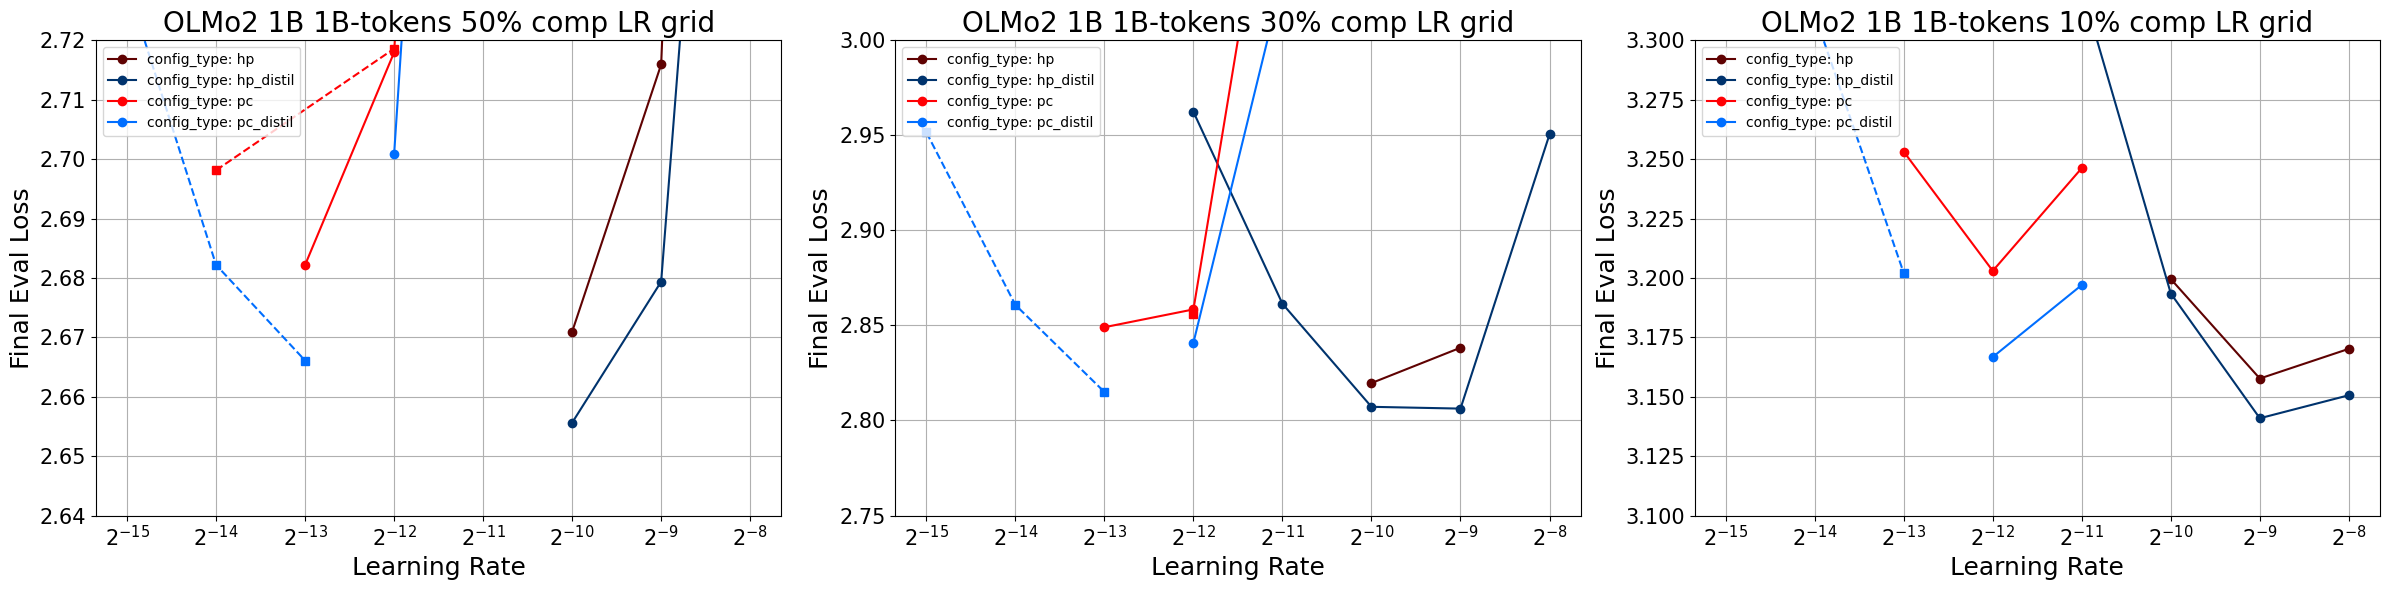

In [17]:
# OLMo2 1B - LR grid at 1B tokens (cols = compression rate). Set ylims once you see the range.
plot_lr_grid_1B("olmo2", "1B", "OLMo2 1B", ylims=[(2.64, 2.72), (2.75, 3.0), (3.1, 3.3)])


tags: ['1.7B', 'smollm2', '1B_train', '50p']
df shape: (18, 107)
tags: ['1.7B', 'smollm2', '1B_train', '30p']
df shape: (17, 107)
tags: ['1.7B', 'smollm2', '1B_train', '10p']
df shape: (17, 107)


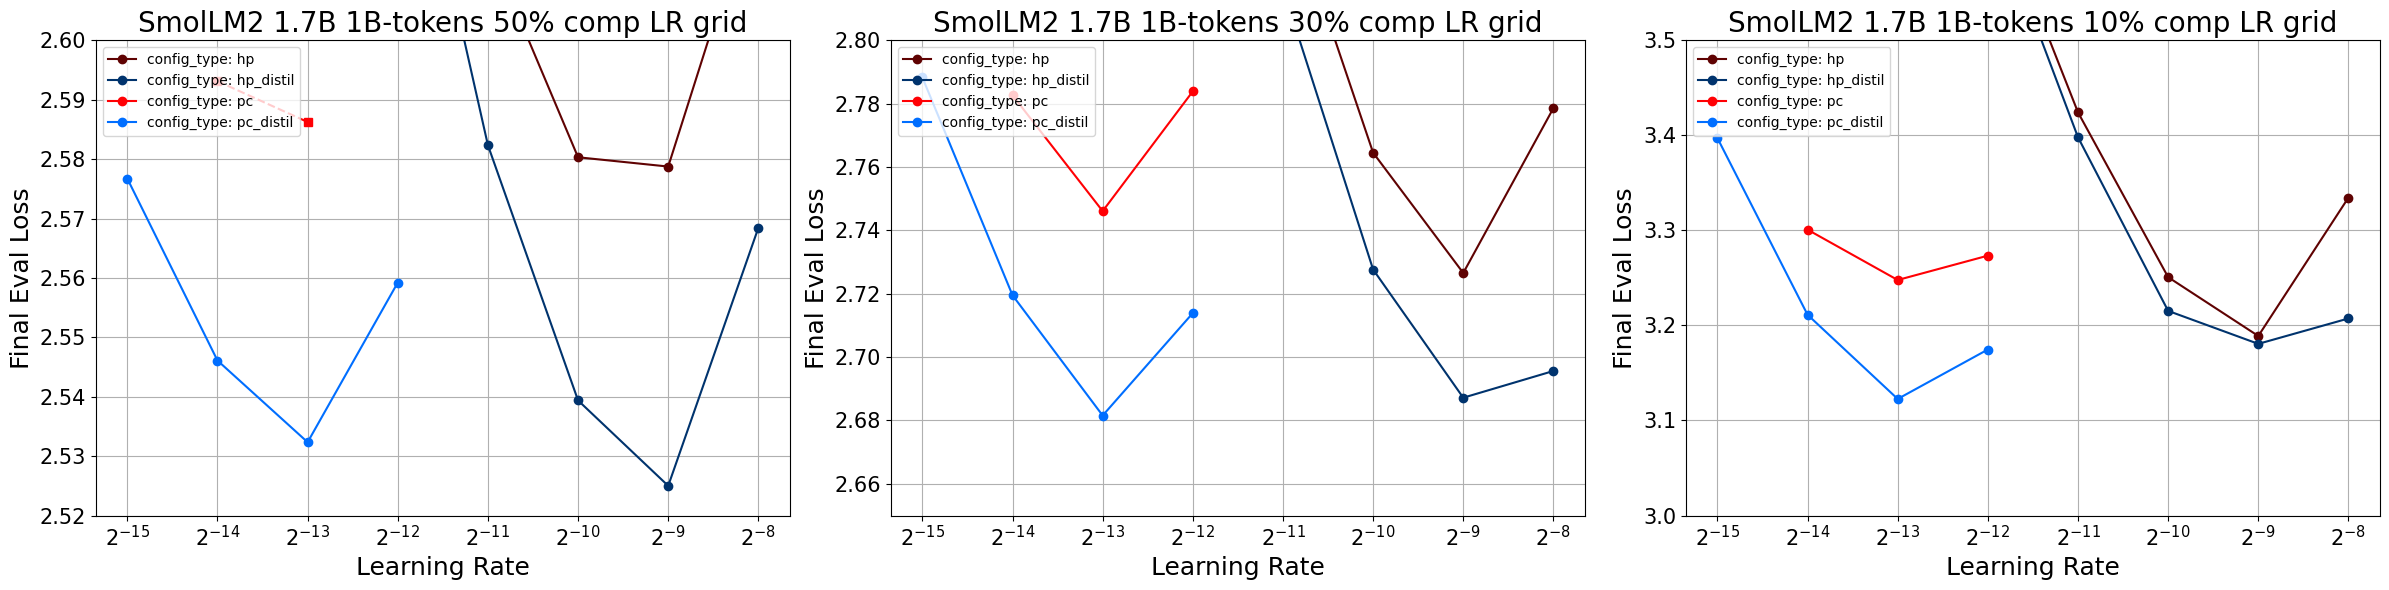

In [16]:
# SmolLM2 1.7B - LR grid at 1B tokens (cols = compression rate). Set ylims once you see the range.
plot_lr_grid_1B("smollm2", "1.7B", "SmolLM2 1.7B", ylims=[(2.52, 2.6), (2.65, 2.8), (3.0, 3.5)])
